# Predict CO₂ Emissions in Rwanda
## Exploratory Data Analysis

**Kaggle Competition** | [Playground Series S3E20](https://www.kaggle.com/competitions/playground-series-s3e20)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

from src.data.data_loader import load_data, train_path, test_path, target
plt.style.use('seaborn-v0_8-whitegrid')

In [2]:
train = load_data(train_path)
test = load_data(test_path)

print(f"Train Shape: {train.shape}")
print(f"Test Shape: {test.shape}")
train.head()

Train Shape: (79023, 76)
Test Shape: (24353, 75)


,ID_LAT_LON_YEAR_WEEK,latitude,longitude,year,week_no,SulphurDioxide_SO2_column_number_density,SulphurDioxide_SO2_column_number_density_amf,SulphurDioxide_SO2_slant_column_number_density,SulphurDioxide_cloud_fraction,SulphurDioxide_sensor_azimuth_angle,...,Cloud_cloud_top_height,Cloud_cloud_base_pressure,Cloud_cloud_base_height,Cloud_cloud_optical_depth,Cloud_surface_albedo,Cloud_sensor_azimuth_angle,Cloud_sensor_zenith_angle,Cloud_solar_azimuth_angle,Cloud_solar_zenith_angle,emission
0,ID_-0.510_29.290_2019_00,-0.51,29.29,2019,0,-0.000108,0.603019,-0.000065,0.255668,-98.593887,...,3664.436218,61085.809570,2615.120483,15.568533,0.272292,-12.628986,35.632416,-138.786423,30.752140,3.750994
1,ID_-0.510_29.290_2019_01,-0.51,29.29,2019,1,0.000021,0.728214,0.000014,0.130988,16.592861,...,3651.190311,66969.478735,3174.572424,8.690601,0.256830,30.359375,39.557633,-145.183930,27.251779,4.025176
2,ID_-0.510_29.290_2019_02,-0.51,29.29,2019,2,0.000514,0.748199,0.000385,0.110018,72.795837,...,4216.986492,60068.894448,3516.282669,21.103410,0.251101,15.377883,30.401823,-142.519545,26.193296,4.231381
3,ID_-0.510_29.290_2019_03,-0.51,29.29,2019,3,NaN,NaN,NaN,NaN,NaN,...,5228.507736,51064.547339,4180.973322,15.386899,0.262043,-11.293399,24.380357,-132.665828,28.829155,4.305286
4,ID_-0.510_29.290_2019_04,-0.51,29.29,2019,4,-0.000079,0.676296,-0.000048,0.121164,4.121269,...,3980.598120,63751.125781,3355.710107,8.114694,0.235847,38.532263,37.392979,-141.509805,22.204612,4.347317


---

## 1. Dataset Overview

In [3]:
SENSOR_GROUPS = {
    "SO₂": [c for c in train.columns if c.startswith("SulphurDioxide")],
    "CO": [c for c in train.columns if c.startswith("CarbonMonoxide")],
    "NO₂": [c for c in train.columns if c.startswith("NitrogenDioxide")],
    "HCHO": [c for c in train.columns if c.startswith("Formaldehyde")],
    "Aerosol": [c for c in train.columns if c.startswith("UvAerosol")],
    "O₃": [c for c in train.columns if c.startswith("Ozone")],
    "Cloud": [c for c in train.columns if c.startswith("Cloud")],
    "Spatio-temporal": ["latitude", "longitude", "year", "week_no"],
}

print("Column counts per sensor group:")
for g, cols in SENSOR_GROUPS.items():
    print(f"  {g:<18} : {len(cols)} columns")

print(f"\nTotal feature columns : {train.shape[1] - 2}")  # -2 for ID + target
print(f"Target: emission")

Column counts per sensor group:
  SO₂                : 9 columns
  CO                 : 8 columns
  NO₂                : 12 columns
  HCHO               : 8 columns
  Aerosol            : 13 columns
  O₃                 : 9 columns
  Cloud              : 11 columns
  Spatio-temporal    : 4 columns

Total feature columns : 74
Target: emission


---

## 2. Target Variable - `emission`

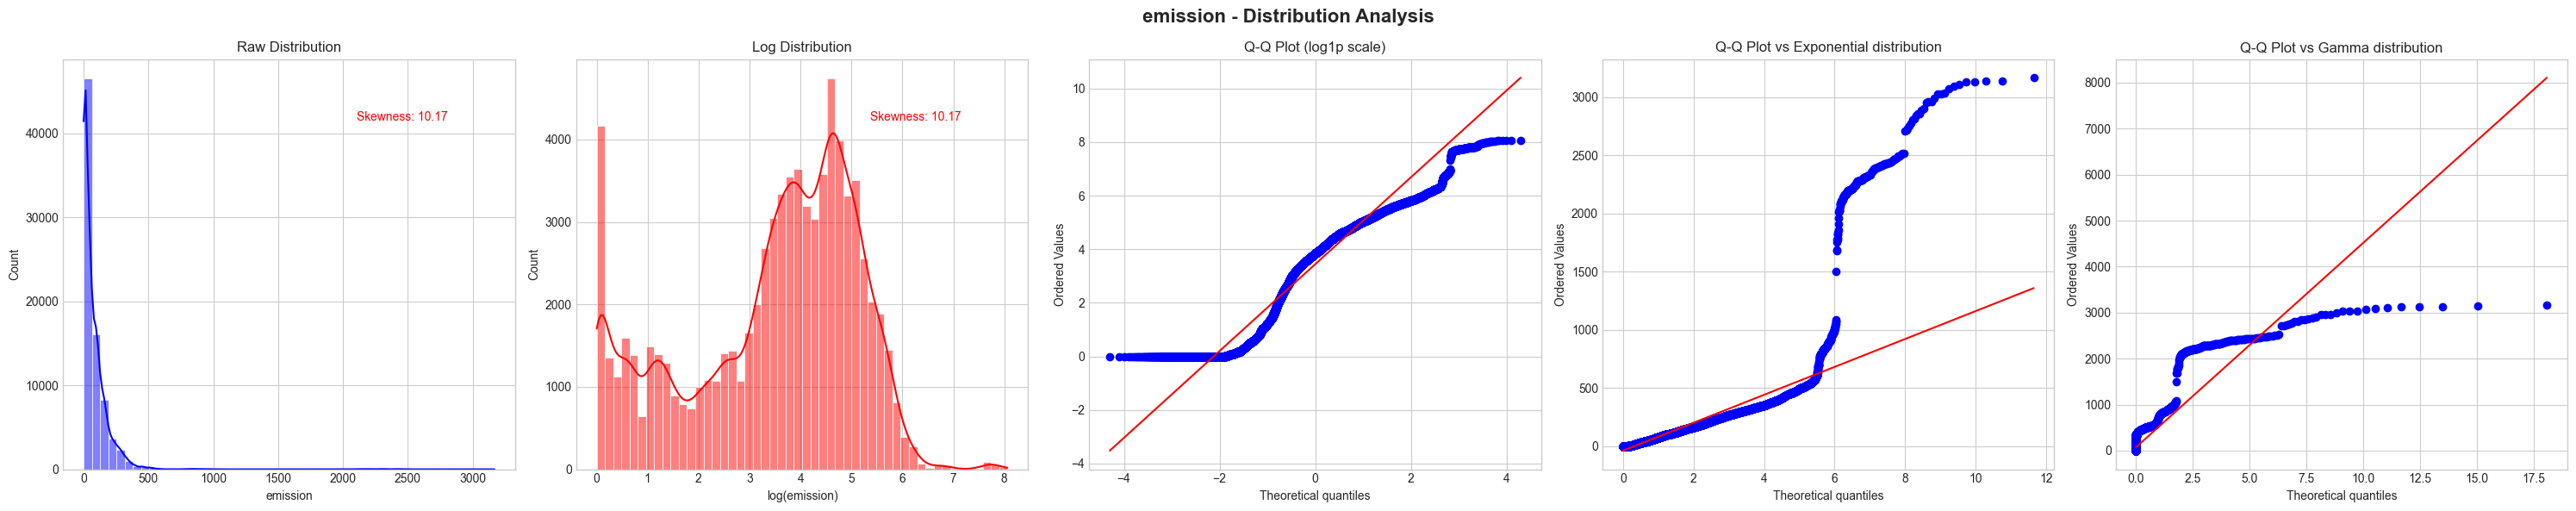

In [4]:
y = train[target]

fig, axes = plt.subplots(nrows=1, ncols=5, figsize=(30, 6))
fig.suptitle("emission - Distribution Analysis", fontsize=16, fontweight="bold")

sns.histplot(data=y,
             kde=True,
             color="b",
             bins=50,
             ax=axes[0])
axes[0].set_title("Raw Distribution")
axes[0].set_xlabel("emission")
skew_raw = y.skew()
axes[0].annotate(f"Skewness: {skew_raw:.2f}", xy=(0.65, 0.85), xycoords="axes fraction", fontsize=10, color="r")

y_log = np.log1p(y)
sns.histplot(data=y_log,
             kde=True,
             color="r",
             bins=50,
             ax=axes[1])

axes[1].set_title("Log Distribution")
axes[1].set_xlabel("log(emission)")
skew_log = y_log.skew()
axes[1].annotate(f"Skewness: {skew_raw:.2f}", xy=(0.65, 0.85), xycoords="axes fraction", fontsize=10, color="r")

stats.probplot(y_log, plot=axes[2])
axes[2].set_title('Q-Q Plot (log1p scale)')


stats.probplot(y, dist="expon", plot=axes[3])
axes[3].set_title("Q-Q Plot vs Exponential distribution")

shape, loc, scale = stats.gamma.fit(y)
stats.probplot(y, dist=stats.gamma(shape, loc=loc, scale=scale), plot=axes[4])
axes[4].set_title("Q-Q Plot vs Gamma distribution")

plt.tight_layout()

---

## 3. Missing Values Analysis

In [5]:
def missing_summary(df: pd.DataFrame, label: str = "Dataset") -> pd.DataFrame:
    miss     = df.isna().sum()
    miss     = miss[miss > 0].sort_values(ascending=False)
    miss_pct = (miss / len(df) * 100).round(2)
    return pd.DataFrame(
        {"Missing": miss, "Missing (%)": miss_pct}
    ).rename_axis(f"{label} — Column")

In [6]:
train_miss = missing_summary(train, "Train")
test_miss  = missing_summary(test,  "Test")

print(f"Train — columns with missing values: {len(train_miss)}")
print(f"Test  — columns with missing values: {len(test_miss)}")

Train — columns with missing values: 70
Test  — columns with missing values: 70


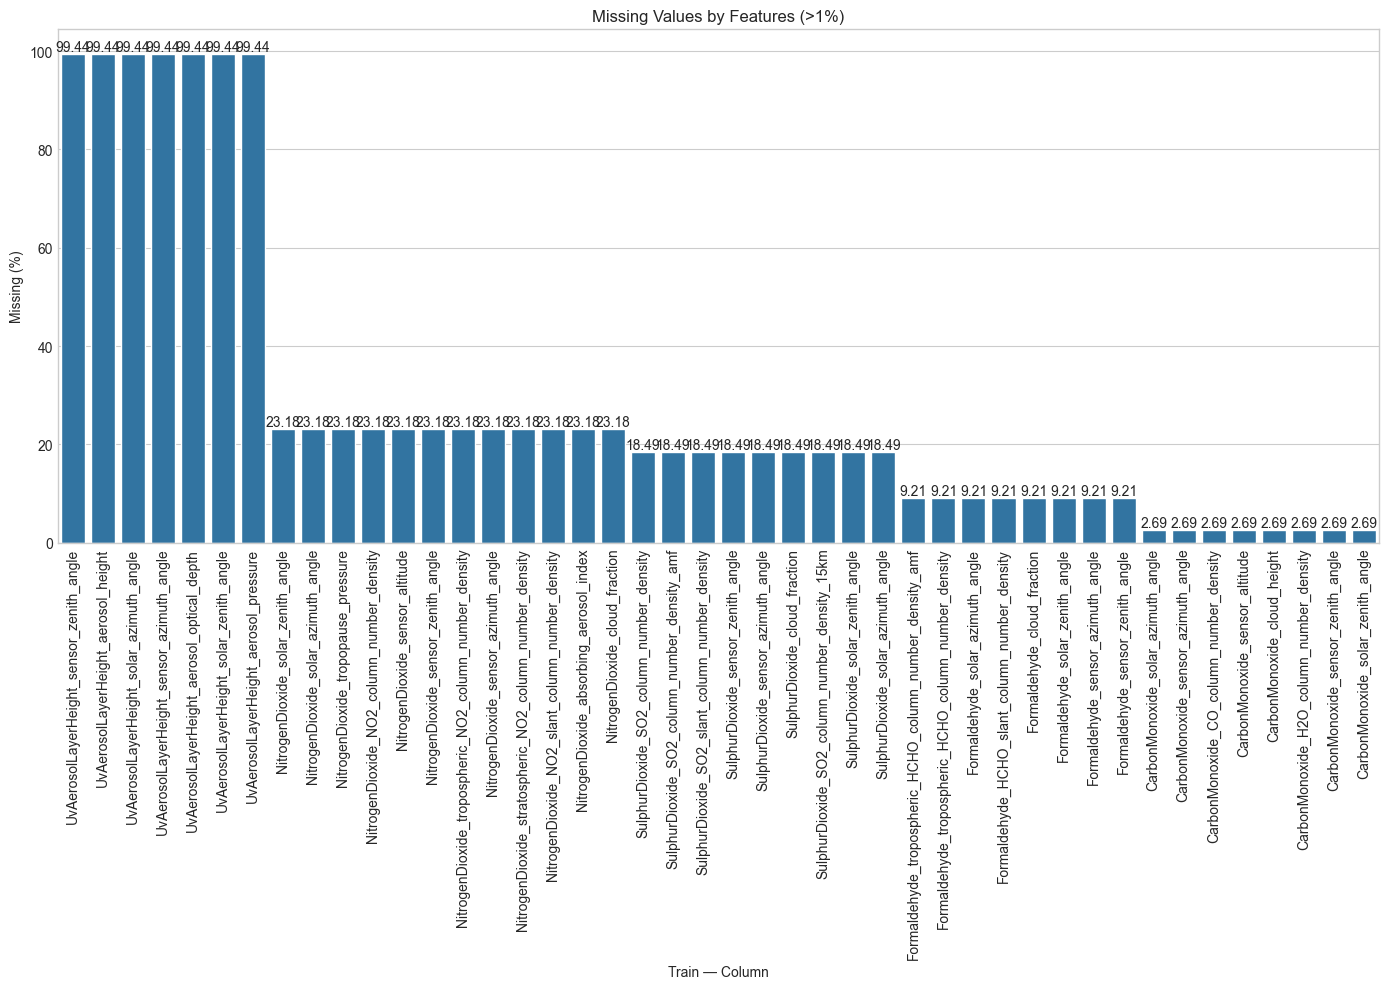

In [7]:
fig, ax = plt.subplots(figsize=(14, 10))
train_miss_top = train_miss.query("`Missing (%)` > 1")

sns.barplot(x=train_miss_top.index,
            y=train_miss_top["Missing (%)"],
            ax=ax)
ax.tick_params(axis='x', rotation=90)
ax.bar_label(ax.containers[0], fontsize=10)
ax.set_title("Missing Values by Features (>1%)")
plt.tight_layout()



In [8]:
print("Missing rate per sensor group (train):")
for group, cols in SENSOR_GROUPS.items():
    present = [c for c in cols if c in train.columns]
    if not present:
        continue
    miss_pct = train[present].isna().mean().mean() * 100
    print(f"  {group:<18} : {miss_pct:.1f}%")

Missing rate per sensor group (train):
  SO₂                : 18.5%
  CO                 : 2.7%
  NO₂                : 23.2%
  HCHO               : 9.2%
  Aerosol            : 53.9%
  O₃                 : 0.7%
  Cloud              : 0.6%
  Spatio-temporal    : 0.0%


---
## 4. Temporal Analysis

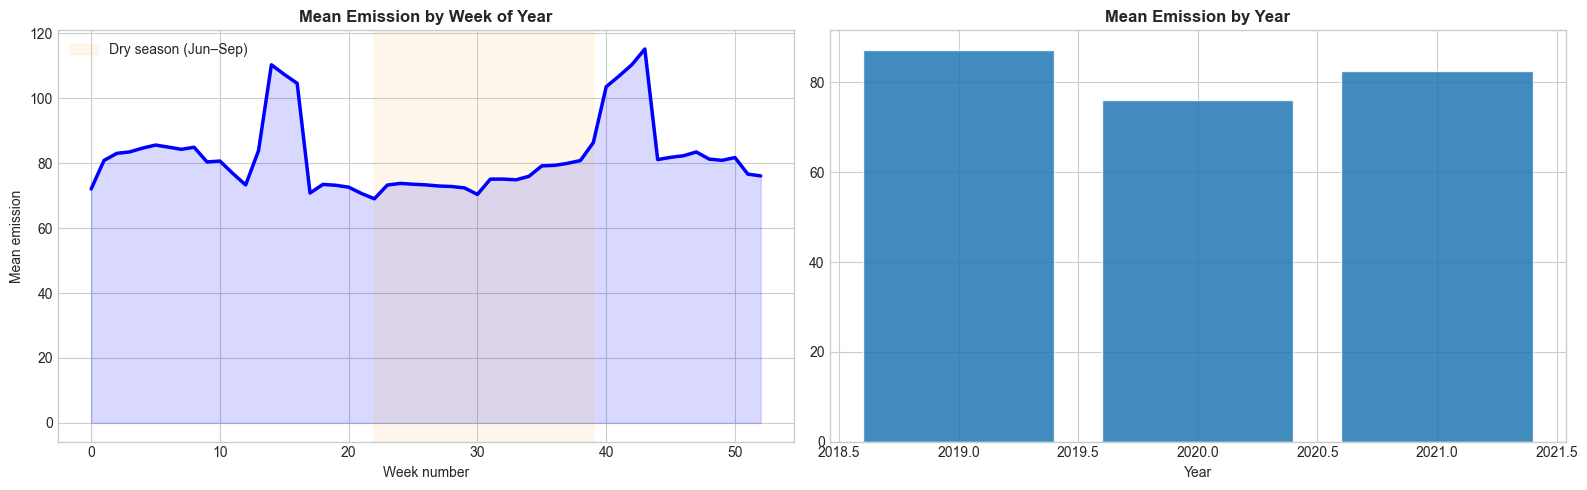

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))


weekly = train.groupby("week_no")["emission"].mean()
axes[0].plot(weekly.index, weekly.values, color="b", linewidth=2.5)
axes[0].fill_between(weekly.index, weekly.values, alpha=0.15, color="b")
axes[0].axvspan(22, 39, alpha=0.08, color="orange", label="Dry season (Jun–Sep)")
axes[0].legend()
axes[0].set_title("Mean Emission by Week of Year", fontweight="bold")
axes[0].set_xlabel("Week number")
axes[0].set_ylabel("Mean emission")


yearly = train.groupby("year")["emission"].mean()
axes[1].bar(yearly.index, yearly.values, alpha=0.85)
axes[1].set_title("Mean Emission by Year", fontweight="bold")
axes[1].set_xlabel("Year")

plt.tight_layout()

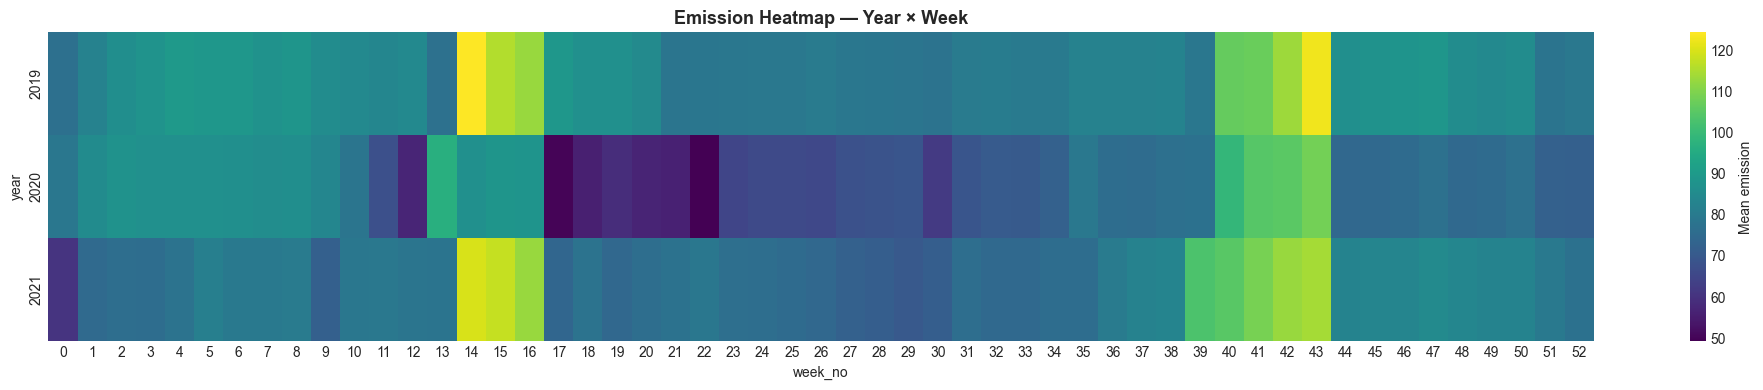

In [10]:
pivot = train.pivot_table(values="emission", index="year", columns="week_no", aggfunc="mean")

fig, ax = plt.subplots(figsize=(20, 4))
sns.heatmap(data=pivot,
            cmap="viridis",
            cbar_kws={"label": "Mean emission"},
            ax=ax)
ax.set_title("Emission Heatmap — Year × Week", fontsize=13, fontweight="bold")
plt.tight_layout()

We see a pattern of increasing emissions from weeks 14 to 16 and from weeks 39 to 43.

---
## 5. Spatial Analysis

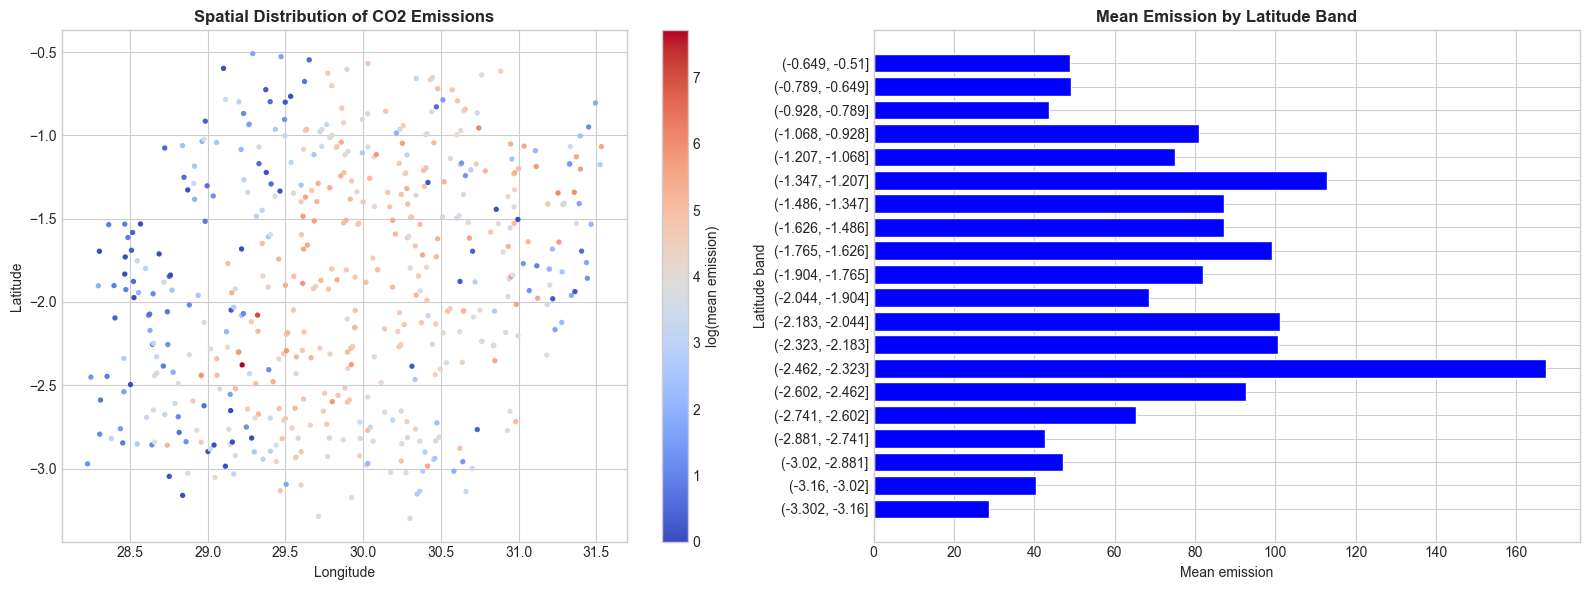

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

loc_mean = train.groupby(["latitude", "longitude"])["emission"].mean().reset_index()
sc = axes[0].scatter(
    loc_mean["longitude"], loc_mean["latitude"],
    c=np.log1p(loc_mean["emission"].clip(lower=0)),
    cmap="coolwarm", s=8,
)
plt.colorbar(sc, ax=axes[0], label="log(mean emission)")
axes[0].set_title("Spatial Distribution of CO2 Emissions", fontweight="bold")
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")

lat_bins = pd.cut(train["latitude"], bins=20)
lat_profile = train.groupby(lat_bins, observed=True)["emission"].mean()
axes[1].barh([str(i) for i in lat_profile.index], lat_profile.values, color="b")
axes[1].set_title("Mean Emission by Latitude Band", fontweight="bold")
axes[1].set_xlabel("Mean emission")
axes[1].set_ylabel("Latitude band")

plt.tight_layout()

We observe that emissions are higher in the central latitudes, indicating a concentration of CO₂ in that region.

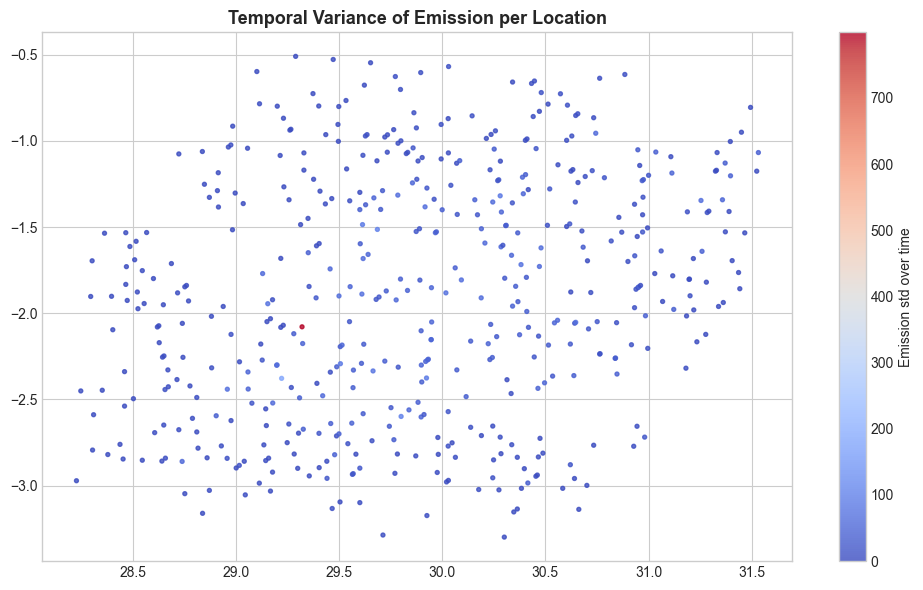

In [12]:
loc_std = train.groupby(['latitude', 'longitude'])['emission'].std().reset_index()
loc_std.columns = ['latitude', 'longitude', 'emission_std']

fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(
    loc_std['longitude'], loc_std['latitude'],
    c=loc_std['emission_std'],
    cmap='coolwarm', s=8, alpha=0.8
)
plt.colorbar(sc, ax=ax, label='Emission std over time')
ax.set_title('Temporal Variance of Emission per Location', fontsize=13, fontweight='bold')
plt.tight_layout()

---
## 6. Sensor Feature Analysis

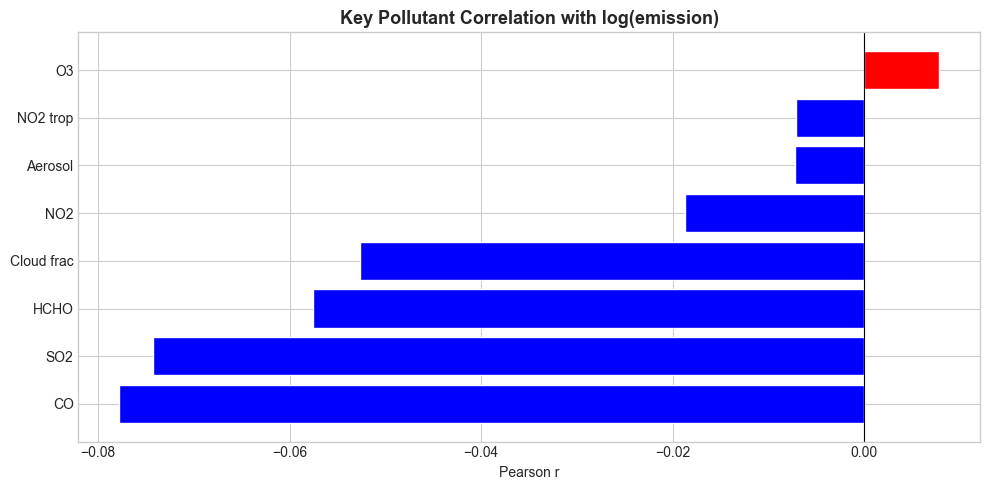

In [13]:
key_cols_per_group = {
    "SO2"      : "SulphurDioxide_SO2_column_number_density",
    "CO"       : "CarbonMonoxide_CO_column_number_density",
    "NO2"      : "NitrogenDioxide_NO2_column_number_density",
    "NO2 trop" : "NitrogenDioxide_tropospheric_NO2_column_number_density",
    "HCHO"     : "Formaldehyde_tropospheric_HCHO_column_number_density",
    "Aerosol"  : "UvAerosolIndex_absorbing_aerosol_index",
    "O3"       : "Ozone_O3_column_number_density",
    "Cloud frac": "Cloud_cloud_fraction",
}

records = []
for label, col in key_cols_per_group.items():
    if col in train.columns:
        r = train[col].corr(y_log)
        records.append({"Pollutant": label, "Pearson r": r})

corr_df = pd.DataFrame(records).sort_values("Pearson r")

fig, ax = plt.subplots(figsize=(10, 5))

colors = ["r" if v > 0 else "b" for v in corr_df["Pearson r"]]
ax.barh(corr_df["Pollutant"], corr_df["Pearson r"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)

ax.set_title(r"Key Pollutant Correlation with log(emission)", fontsize=13, fontweight="bold")
ax.set_xlabel("Pearson r")

plt.tight_layout()

In [14]:
sensor_cols_all = []
for group, cols in SENSOR_GROUPS.items():
    sensor_cols_all.extend([c for c in cols if c in train.columns])

corr_mat = train[sensor_cols_all + ["emission"]].corr()
emission_corr = corr_mat["emission"].drop("emission").abs().sort_values(ascending=False)

top15 = emission_corr.head(15)
print("Top 15 features most correlated with emission:")
print(top15.to_string())

Top 15 features most correlated with emission:
longitude                                                   0.102746
UvAerosolLayerHeight_aerosol_height                         0.069008
UvAerosolLayerHeight_aerosol_pressure                       0.068138
Cloud_surface_albedo                                        0.046587
CarbonMonoxide_H2O_column_number_density                    0.043217
CarbonMonoxide_CO_column_number_density                     0.041328
Formaldehyde_tropospheric_HCHO_column_number_density_amf    0.040263
UvAerosolLayerHeight_aerosol_optical_depth                  0.040156
UvAerosolLayerHeight_sensor_azimuth_angle                   0.035142
NitrogenDioxide_solar_azimuth_angle                         0.033417
Formaldehyde_tropospheric_HCHO_column_number_density        0.033333
SulphurDioxide_solar_azimuth_angle                          0.032338
Formaldehyde_solar_azimuth_angle                            0.030815
NitrogenDioxide_sensor_altitude                         

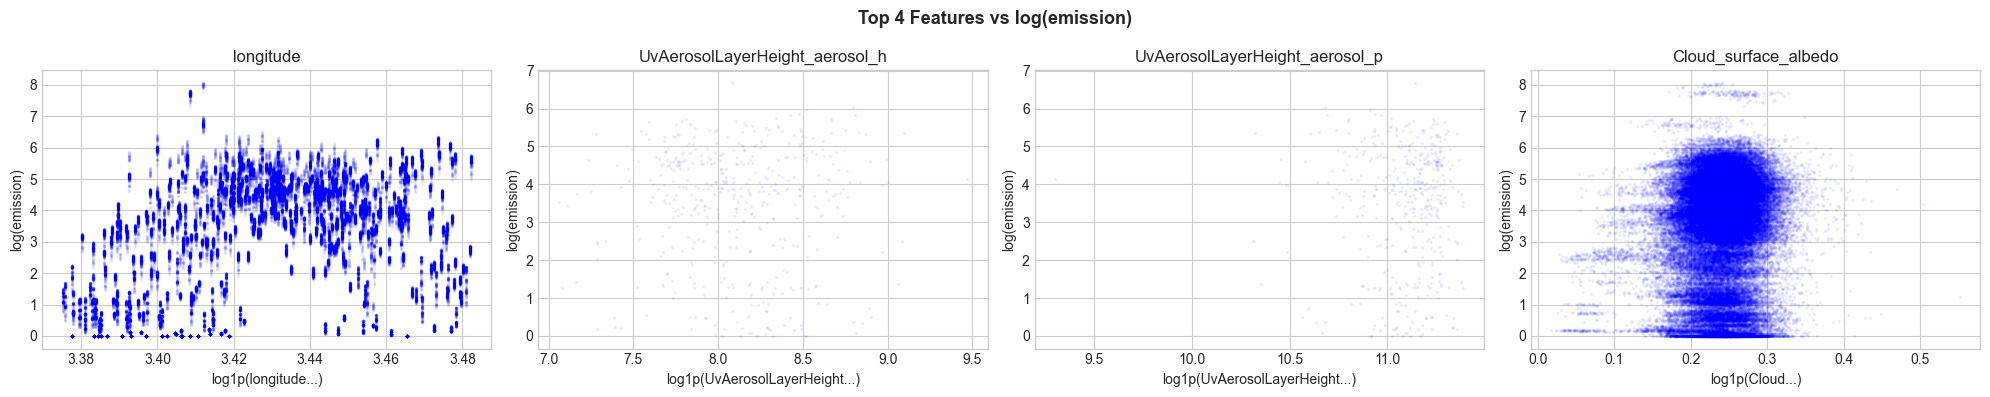

In [15]:
top4 = top15.head(4).index.tolist()
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
fig.suptitle("Top 4 Features vs log(emission)", fontsize=13, fontweight="bold")

for ax, col in zip(axes, top4):
    x = train[col].clip(lower=0)
    ax.scatter(np.log1p(x), y_log, alpha=0.05, s=2, color="b")
    ax.set_xlabel(f"log1p({col.split("_")[0]}...)")
    ax.set_ylabel("log(emission)")
    ax.set_title(col[:30])

plt.tight_layout()

---
## 7. Feature Engineering Insights

In [16]:
df = train.copy()

df["month"]        = ((df["week_no"] - 1) // 4 + 1).clip(1, 12)
df["is_dry_season"] = ((df["week_no"] >= 22) & (df["week_no"] <= 39)).astype(int)
df["week_sin"]     = np.sin(2 * np.pi * df["week_no"] / 52)
df["week_cos"]     = np.cos(2 * np.pi * df["week_no"] / 52)

so2  = df["SulphurDioxide_SO2_column_number_density"].replace(0, np.nan)
no2  = df["NitrogenDioxide_NO2_column_number_density"].replace(0, np.nan)
co   = df["CarbonMonoxide_CO_column_number_density"].replace(0, np.nan)
hcho = df["Formaldehyde_tropospheric_HCHO_column_number_density"].replace(0, np.nan)

df["NO2_SO2_ratio"]  = no2 / so2
df["CO_NO2_ratio"]   = co  / no2
df["HCHO_NO2_ratio"] = hcho / no2

eng_features = ["month", "is_dry_season", "week_sin", "week_cos",
                "NO2_SO2_ratio", "CO_NO2_ratio", "HCHO_NO2_ratio"]

eng_corr = {f: df[f].corr(y_log) for f in eng_features if f in df.columns}
eng_corr_df = pd.Series(eng_corr).sort_values()
print("Engineered feature correlations with log(emission):")
print(eng_corr_df.to_string())

Engineered feature correlations with log(emission):
is_dry_season    -0.015866
week_sin         -0.015801
CO_NO2_ratio     -0.012302
HCHO_NO2_ratio   -0.001924
NO2_SO2_ratio     0.002155
month             0.014567
week_cos          0.016657


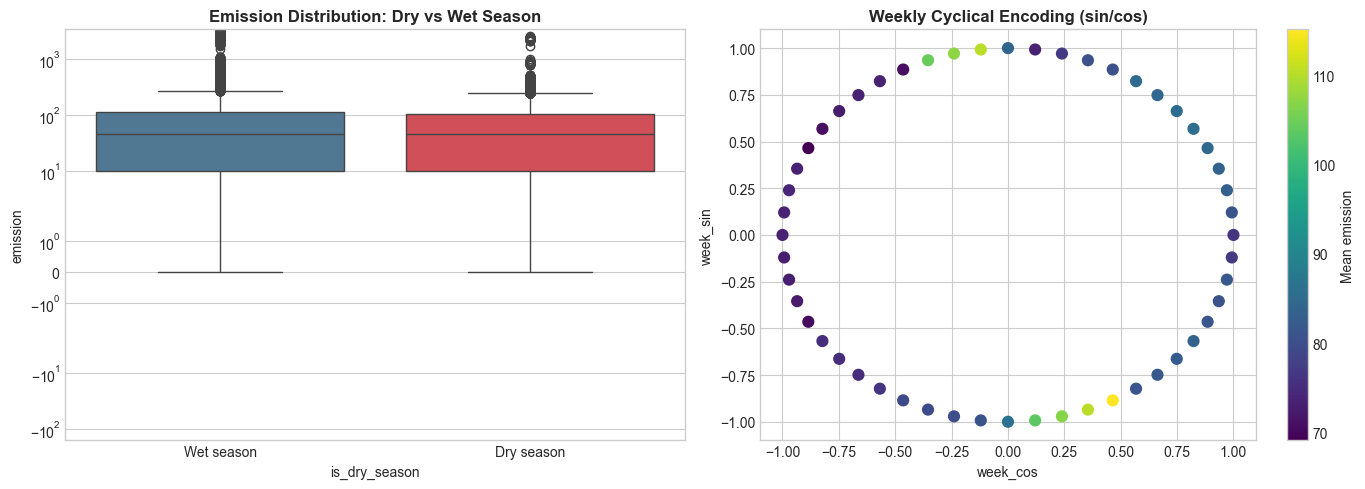

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x="is_dry_season", y="emission",
            palette=["#457B9D", "#E63946"], ax=axes[0],
            hue="is_dry_season", legend=False)
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(["Wet season", "Dry season"])
axes[0].set_title("Emission Distribution: Dry vs Wet Season", fontweight="bold")
axes[0].set_yscale("symlog")

# Cyclical week encoding
theta = 2 * np.pi * np.arange(1, 53) / 52
weekly_mean = df.groupby("week_no")["emission"].mean().reindex(range(1, 53))
sc = axes[1].scatter(np.cos(theta), np.sin(theta),
                     c=weekly_mean.values, cmap="viridis", s=60)
plt.colorbar(sc, ax=axes[1], label="Mean emission")
axes[1].set_title("Weekly Cyclical Encoding (sin/cos)", fontweight="bold")
axes[1].set_xlabel("week_cos")
axes[1].set_ylabel("week_sin")

plt.tight_layout()

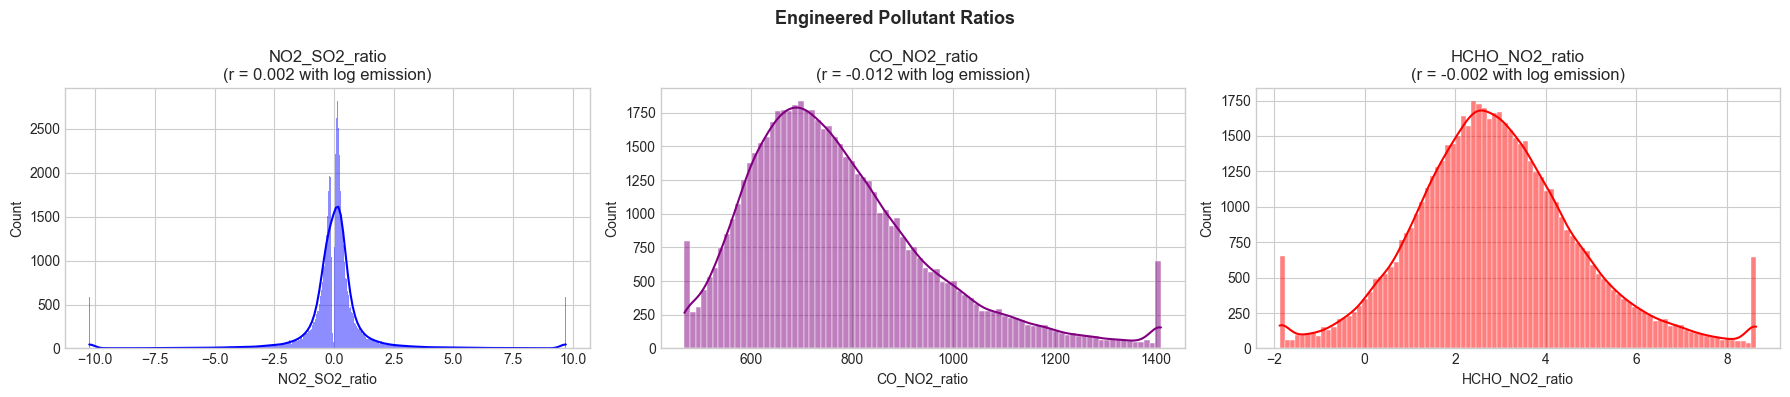

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
fig.suptitle("Engineered Pollutant Ratios", fontsize=13, fontweight="bold")

for ax, col, color in zip(axes,
                           ["NO2_SO2_ratio", "CO_NO2_ratio", "HCHO_NO2_ratio"],
                           ["b", "purple", "r"]):
    data = df[col].dropna()
    data_clipped = data.clip(*data.quantile([0.01, 0.99]))
    sns.histplot(data_clipped, kde=True, ax=ax, color=color)
    r = data.corr(y_log)
    ax.set_title(f"{col}\n(r = {r:.3f} with log emission)")

plt.tight_layout()

---
## 8. Sensor Group Distributions

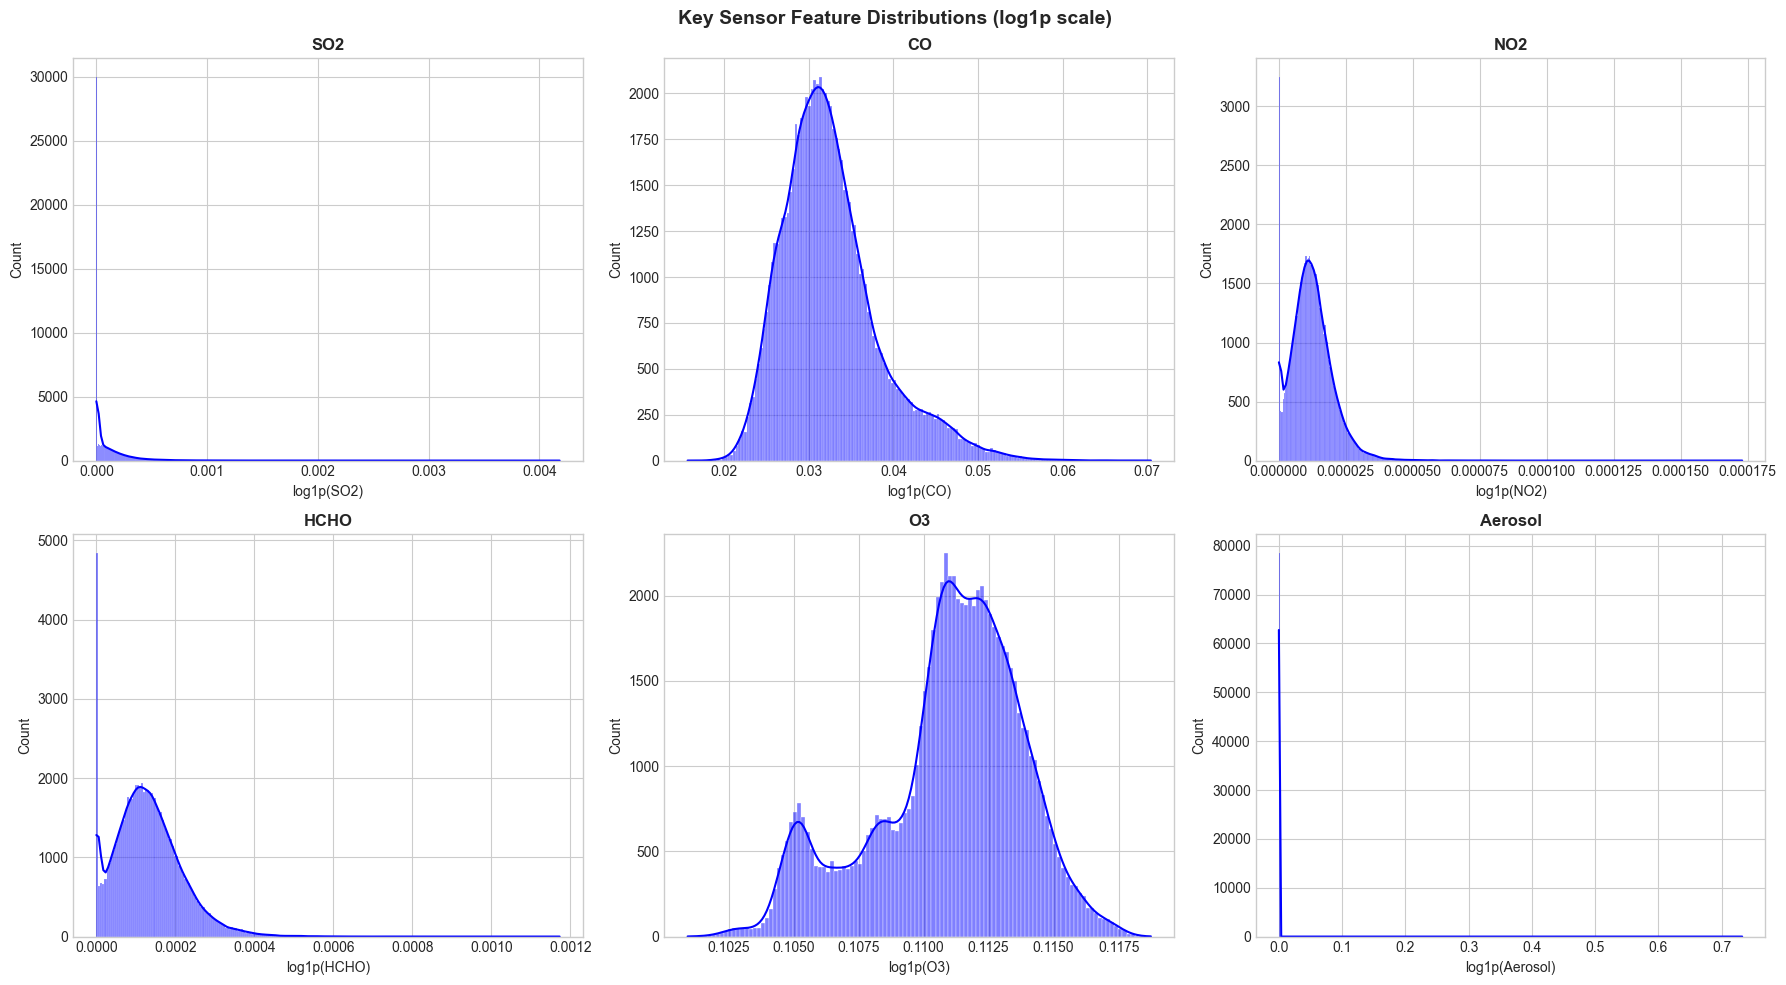

In [19]:
key_per_group = {
    "SO2"      : "SulphurDioxide_SO2_column_number_density",
    "CO"       : "CarbonMonoxide_CO_column_number_density",
    "NO2"      : "NitrogenDioxide_tropospheric_NO2_column_number_density",
    "HCHO"     : "Formaldehyde_tropospheric_HCHO_column_number_density",
    "O3"       : "Ozone_O3_column_number_density",
    "Aerosol"  : "UvAerosolIndex_absorbing_aerosol_index",
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Key Sensor Feature Distributions (log1p scale)", fontsize=14, fontweight="bold")

for ax, (label, col) in zip(axes.flat, key_per_group.items()):
    if col not in train.columns:
        continue
    data = np.log1p(train[col].clip(lower=0).dropna())
    sns.histplot(data, kde=True, ax=ax, color="b")
    ax.set_title(label, fontweight="bold")
    ax.set_xlabel(f"log1p({label})")

plt.tight_layout()

---
## 9. Correlation Heatmap (Top Features)

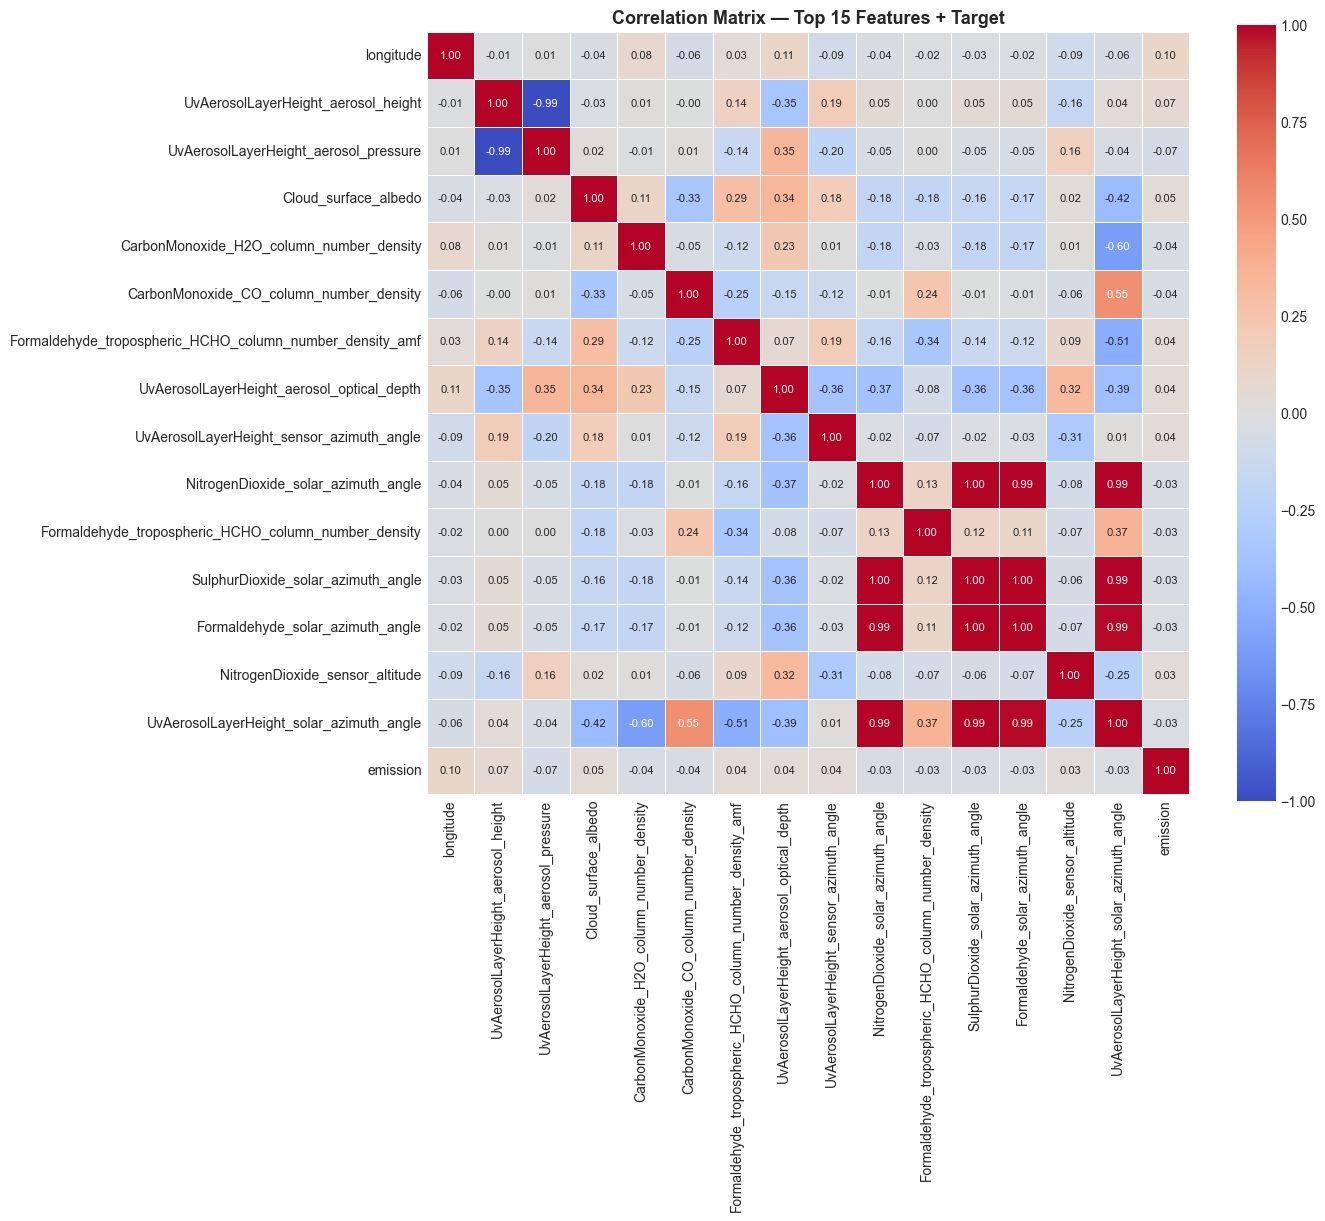

In [20]:
top15_cols = emission_corr.head(15).index.tolist()
plot_cols  = top15_cols + ["emission"]
corr_top15 = train[plot_cols].corr()

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    corr_top15, annot=True, fmt=".2f", cmap="coolwarm",
    square=True, linewidths=0.5, ax=ax,
    annot_kws={"size": 8}, vmin=-1, vmax=1
)
ax.set_title("Correlation Matrix — Top 15 Features + Target", fontsize=13, fontweight="bold")
plt.tight_layout()

---
## 10. Train vs Test Distribution Check

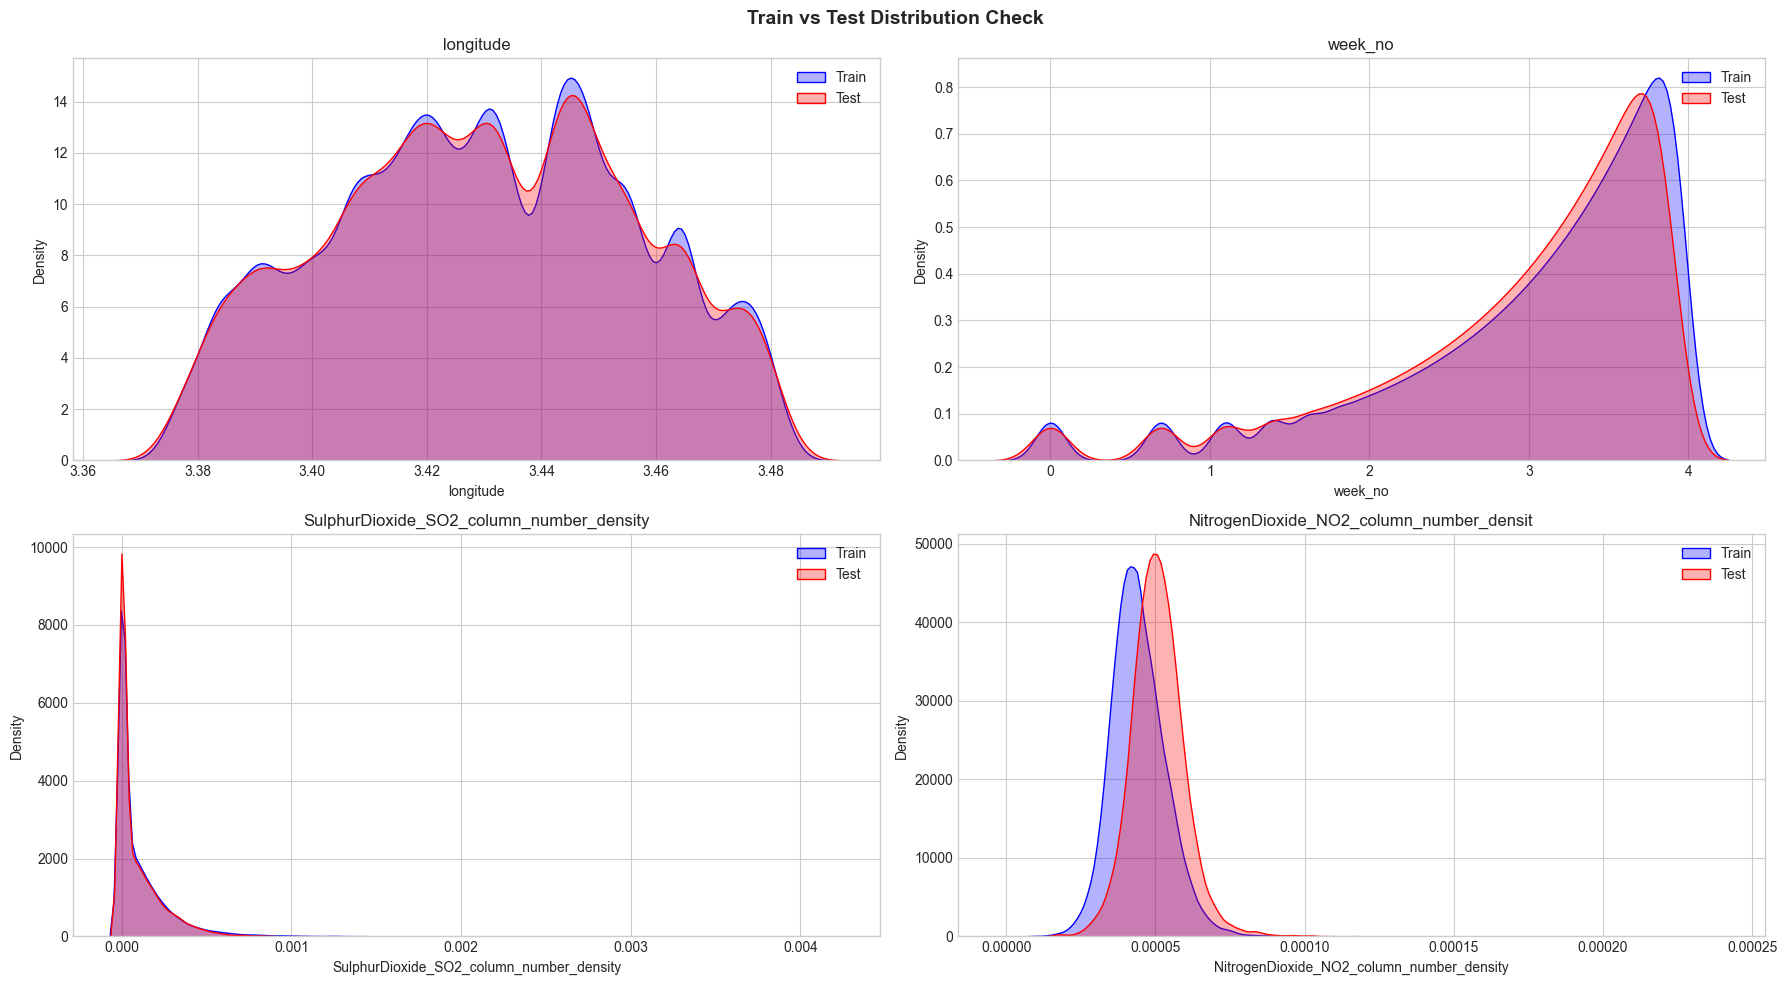

In [21]:
check_cols = ["longitude", "week_no",
              "SulphurDioxide_SO2_column_number_density",
              "NitrogenDioxide_NO2_column_number_density"]

fig, axes = plt.subplots(2, 2, figsize=(18, 10))
fig.suptitle("Train vs Test Distribution Check", fontsize=14, fontweight="bold")

for ax, col in zip(axes.flat, check_cols):
    if col not in train.columns or col not in test.columns:
        continue
    train_vals = np.log1p(train[col].clip(lower=0).dropna()) if train[col].dtype != object else train[col]
    test_vals  = np.log1p(test[col].clip(lower=0).dropna())  if test[col].dtype  != object else test[col]
    sns.kdeplot(train_vals, ax=ax, label="Train", color="b", fill=True, alpha=0.3, warn_singular=False)
    sns.kdeplot(test_vals,  ax=ax, label="Test",  color="r",  fill=True, alpha=0.3, warn_singular=False)
    ax.set_title(col[:40])
    ax.legend()

plt.tight_layout()